In [1]:
import pandas as pd

fixtures = pd.DataFrame([
    ["2026-02-07", "Pakistan", "Netherlands", "Sri Lanka"],
    ["2026-02-07", "West Indies", "Bangladesh", "India"],
    ["2026-02-07", "India", "USA", "India"],

    ["2026-02-08", "New Zealand", "Afghanistan", "India"],
    ["2026-02-08", "England", "Nepal", "India"],
    ["2026-02-08", "Sri Lanka", "Ireland", "Sri Lanka"],

    ["2026-02-09", "Bangladesh", "Italy", "India"],
    ["2026-02-09", "Zimbabwe", "Oman", "Sri Lanka"],
    ["2026-02-09", "South Africa", "Canada", "India"],

    ["2026-02-10", "Netherlands", "Namibia", "India"],
    ["2026-02-10", "New Zealand", "United Arab Emirates", "India"],
    ["2026-02-10", "Pakistan", "USA", "Sri Lanka"],

    ["2026-02-11", "South Africa", "Afghanistan", "India"],
    ["2026-02-11", "Australia", "Ireland", "Sri Lanka"],
    ["2026-02-11", "England", "West Indies", "India"],

    ["2026-02-12", "Sri Lanka", "Oman", "Sri Lanka"],
    ["2026-02-12", "Nepal", "Italy", "India"],
    ["2026-02-12", "India", "Namibia", "India"],

    ["2026-02-13", "Australia", "Zimbabwe", "Sri Lanka"],
    ["2026-02-13", "Canada", "United Arab Emirates", "India"],
    ["2026-02-13", "USA", "Netherlands", "India"],

    ["2026-02-14", "Ireland", "Oman", "Sri Lanka"],
    ["2026-02-14", "England", "Bangladesh", "India"],
    ["2026-02-14", "New Zealand", "South Africa", "India"],

    ["2026-02-15", "West Indies", "Nepal", "India"],
    ["2026-02-15", "USA", "Namibia", "India"],
    ["2026-02-15", "India", "Pakistan", "Sri Lanka"],

    ["2026-02-16", "Afghanistan", "United Arab Emirates", "India"],
    ["2026-02-16", "England", "Italy", "India"],
    ["2026-02-16", "Australia", "Sri Lanka", "Sri Lanka"],

    ["2026-02-17", "New Zealand", "Canada", "India"],
    ["2026-02-17", "Ireland", "Zimbabwe", "Sri Lanka"],
    ["2026-02-17", "Bangladesh", "Nepal", "India"],

    ["2026-02-18", "South Africa", "United Arab Emirates", "India"],
    ["2026-02-18", "Pakistan", "Namibia", "Sri Lanka"],
    ["2026-02-18", "India", "Netherlands", "India"],

    ["2026-02-19", "West Indies", "Italy", "India"],
    ["2026-02-19", "Sri Lanka", "Zimbabwe", "Sri Lanka"],
    ["2026-02-19", "Afghanistan", "Canada", "India"],

    ["2026-02-20", "Australia", "Oman", "Sri Lanka"]
], columns=["Match Date", "Team1", "Team2", "Venue Country"])

fixtures["Match Date"] = pd.to_datetime(fixtures["Match Date"])


C:\Users\arman\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
fixtures.head()

,Match Date,Team1,Team2,Venue Country
0,2026-02-07,Pakistan,Netherlands,Sri Lanka
1,2026-02-07,West Indies,Bangladesh,India
2,2026-02-07,India,USA,India
3,2026-02-08,New Zealand,Afghanistan,India
4,2026-02-08,England,Nepal,India


In [3]:
fixtures.shape

(40, 4)

In [ ]:
import pandas as pd

team_df = pd.read_csv("../Dataset/team_stats.csv")
team_df["Match Date"] = pd.to_datetime(team_df["Match Date"])

In [5]:
import pickle

with open("t20_model.pkl", "rb") as f:
    model = pickle.load(f)

In [8]:
latest_team_stats = (
    team_df.sort_values("Match Date")
           .groupby("Team")
           .tail(1)
           .set_index("Team")
)

In [11]:
global_stats = {
    "win_pct_last_10": team_df["win_pct_last_10"].mean(),
    "avg_runs_scored_last_10": team_df["avg_runs_scored_last_10"].mean(),
    "avg_runs_conceded_last_10": team_df["avg_runs_conceded_last_10"].mean(),
}

In [12]:
def get_team_stats(team):
    if team in latest_team_stats.index:
        return latest_team_stats.loc[team]
    else:
        # fallback for new / weak-data teams (USA, Nepal, Italy, etc.)
        return pd.Series(global_stats)

def build_match_features(team1, team2):
    t1 = get_team_stats(team1)
    t2 = get_team_stats(team2)

    return pd.DataFrame([{
        "win_pct_diff": t1["win_pct_last_10"] - t2["win_pct_last_10"],
        "avg_runs_scored_diff": t1["avg_runs_scored_last_10"] - t2["avg_runs_scored_last_10"],
        "avg_runs_conceded_diff": t1["avg_runs_conceded_last_10"] - t2["avg_runs_conceded_last_10"],
        "toss_advantage": 0
    }])

In [13]:
predictions = []

for _, r in fixtures.iterrows():
    X_match = build_match_features(r["Team1"], r["Team2"])
    p_team1 = model.predict_proba(X_match)[0, 1]

    predictions.append({
        "Match Date": r["Match Date"],
        "Team1": r["Team1"],
        "Team2": r["Team2"],
        "Team1 Win %": round(p_team1 * 100, 2),
        "Team2 Win %": round((1 - p_team1) * 100, 2),
        "Predicted Winner": r["Team1"] if p_team1 >= 0.5 else r["Team2"]
    })

pred_df = pd.DataFrame(predictions)
pred_df.head()

,Match Date,Team1,Team2,Team1 Win %,Team2 Win %,Predicted Winner
0,2026-02-07,Pakistan,Netherlands,31.73,68.27,Netherlands
1,2026-02-07,West Indies,Bangladesh,57.16,42.84,West Indies
2,2026-02-07,India,USA,84.64,15.36,India
3,2026-02-08,New Zealand,Afghanistan,50.66,49.34,New Zealand
4,2026-02-08,England,Nepal,50.79,49.21,England


## Monte Carlo simulation + standings + qualifiers

In [14]:
team_groups = {
    # Group A
    "India": "A", "Pakistan": "A", "Netherlands": "A", "Namibia": "A", "USA": "A",

    # Group B
    "Australia": "B", "Ireland": "B", "Oman": "B", "Sri Lanka": "B", "Zimbabwe": "B",

    # Group C
    "Bangladesh": "C", "England": "C", "Italy": "C", "Nepal": "C", "West Indies": "C",

    # Group D
    "Afghanistan": "D", "Canada": "D", "New Zealand": "D",
    "South Africa": "D", "United Arab Emirates": "D"
}

In [15]:
import random
from collections import defaultdict

SIMS = 10000

group_points_accumulator = {
    "A": defaultdict(int),
    "B": defaultdict(int),
    "C": defaultdict(int),
    "D": defaultdict(int)
}

qualification_count = defaultdict(int)

for _ in range(SIMS):

    # reset points per simulation
    group_points = {
        "A": defaultdict(int),
        "B": defaultdict(int),
        "C": defaultdict(int),
        "D": defaultdict(int)
    }

    for _, r in pred_df.iterrows():
        p = r["Team1 Win %"] / 100
        winner = r["Team1"] if random.random() < p else r["Team2"]
        grp = team_groups[winner]
        group_points[grp][winner] += 2

    # determine top 2 per group
    for grp in group_points:
        sorted_teams = sorted(
            group_points[grp].items(),
            key=lambda x: x[1],
            reverse=True
        )
        top2 = [team for team, _ in sorted_teams[:2]]

        for t in top2:
            qualification_count[t] += 1

In [16]:
qualification_df = (
    pd.DataFrame(qualification_count.items(), columns=["Team", "Qualification %"])
)

qualification_df["Qualification %"] = (
    qualification_df["Qualification %"] / SIMS * 100
)

qualification_df.sort_values("Qualification %", ascending=False)

,Team,Qualification %
1,India,90.52
2,Oman,63.75
7,Canada,61.38
10,West Indies,61.29
8,Australia,57.94
17,Sri Lanka,56.28
4,Bangladesh,48.88
0,Netherlands,48.51
15,New Zealand,44.24
6,Afghanistan,42.26


In [17]:
import random

def play_match(team1, team2):
    X = build_match_features(team1, team2)
    p = model.predict_proba(X)[0, 1]
    return team1 if random.random() < p else team2

In [18]:
SIMS = 10000
winner_count = {}

for _ in range(SIMS):
    group_points = {
        "A": {}, "B": {}, "C": {}, "D": {}
    }

    for _, r in pred_df.iterrows():
        winner = play_match(r["Team1"], r["Team2"])
        grp = team_groups[winner]
        group_points[grp][winner] = group_points[grp].get(winner, 0) + 2

    # Top 2 from each group
    qualified = []
    for grp in group_points:
        sorted_teams = sorted(
            group_points[grp].items(),
            key=lambda x: x[1],
            reverse=True
        )
        qualified.extend([t[0] for t in sorted_teams[:2]])

    # ---- SUPER 8 (pair sequentially) ----
    super8_winners = []
    for i in range(0, 8, 2):
        super8_winners.append(play_match(qualified[i], qualified[i+1]))

    # ---- SEMI FINALS ----
    semi1 = play_match(super8_winners[0], super8_winners[1])
    semi2 = play_match(super8_winners[2], super8_winners[3])

    # ---- FINAL ----
    champion = play_match(semi1, semi2)

    winner_count[champion] = winner_count.get(champion, 0) + 1

In [19]:
wc_winner_df = pd.DataFrame(
    winner_count.items(), columns=["Team", "World Cup Win %"]
)

wc_winner_df["World Cup Win %"] = (
    wc_winner_df["World Cup Win %"] / SIMS * 100
)

wc_winner_df.sort_values("World Cup Win %", ascending=False)

,Team,World Cup Win %
0,India,43.60
6,Oman,9.87
4,Australia,9.46
9,West Indies,8.69
10,Sri Lanka,5.76
2,Canada,5.01
5,Bangladesh,4.33
8,Netherlands,2.04
3,England,1.88
12,United Arab Emirates,1.79


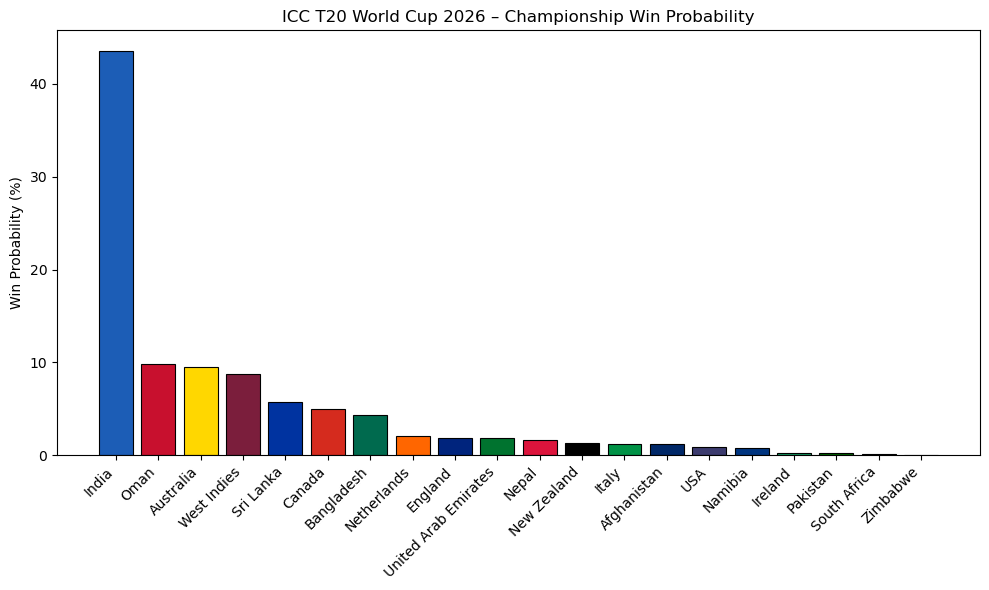

In [69]:
import matplotlib.pyplot as plt

wc_sorted = wc_winner_df.sort_values("World Cup Win %", ascending=False)

colors = [team_colors.get(team, "#808080") for team in wc_sorted["Team"]]

plt.figure(figsize=(10, 6))
plt.bar(
    wc_sorted["Team"],
    wc_sorted["World Cup Win %"],
    color=colors,
    edgecolor="black",
    linewidth=0.8
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Win Probability (%)")
plt.title("ICC T20 World Cup 2026 – Championship Win Probability")
plt.tight_layout()
plt.show()

In [72]:
contenders = [
    "India",
    "Australia",
    "England",
    "South Africa",
    "New Zealand",
    "West Indies",
    "Pakistan",
    "Sri Lanka"
]

In [73]:
wc_display = wc_winner_df[
    wc_winner_df["Team"].isin(contenders)
].copy()

wc_display["Normalized Win %"] = (
    wc_display["World Cup Win %"] /
    wc_display["World Cup Win %"].sum()
) * 100

wc_display = wc_display.sort_values("Normalized Win %", ascending=False)
wc_display

,Team,World Cup Win %,Normalized Win %
0,India,43.60,61.434409
4,Australia,9.46,13.329576
9,West Indies,8.69,12.244610
10,Sri Lanka,5.76,8.116105
3,England,1.88,2.649007
14,New Zealand,1.27,1.789489
18,Pakistan,0.22,0.309990
19,South Africa,0.09,0.126814


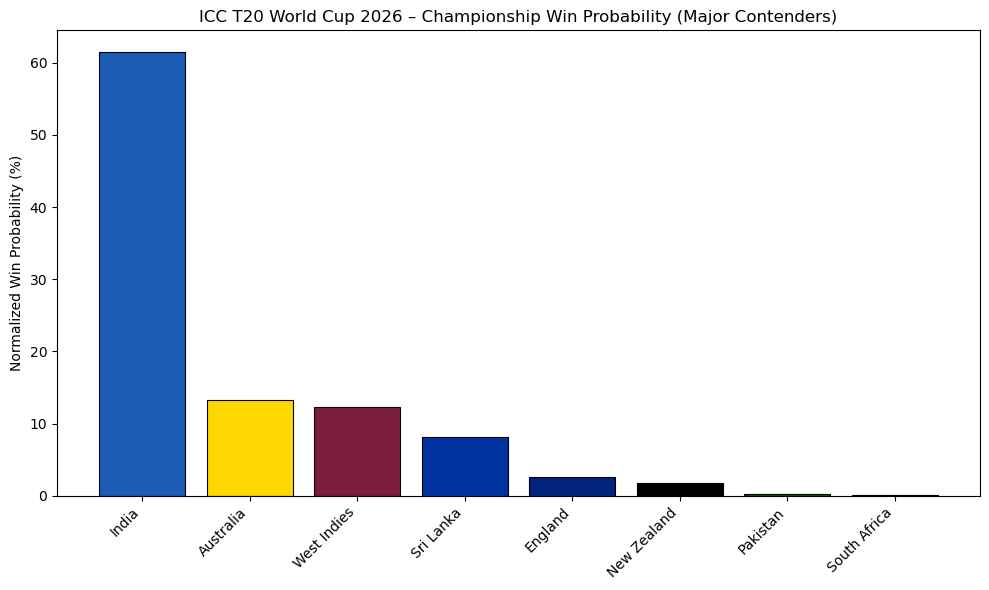

In [74]:
colors = [team_colors.get(team, "#808080") for team in wc_display["Team"]]

plt.figure(figsize=(10, 6))
plt.bar(
    wc_display["Team"],
    wc_display["Normalized Win %"],
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Normalized Win Probability (%)")
plt.title("ICC T20 World Cup 2026 – Championship Win Probability (Major Contenders)")
plt.tight_layout()
plt.show()

In [20]:
group_stage_table = pred_df.copy()

group_stage_table["Match"] = (
    group_stage_table["Team1"] + " vs " + group_stage_table["Team2"]
)

group_stage_table = group_stage_table[[
    "Match Date",
    "Match",
    "Team1 Win %",
    "Team2 Win %",
    "Predicted Winner"
]]

group_stage_table.sort_values("Match Date").reset_index(drop=True)

,Match Date,Match,Team1 Win %,Team2 Win %,Predicted Winner
0,2026-02-07,Pakistan vs Netherlands,31.73,68.27,Netherlands
1,2026-02-07,West Indies vs Bangladesh,57.16,42.84,West Indies
2,2026-02-07,India vs USA,84.64,15.36,India
3,2026-02-08,New Zealand vs Afghanistan,50.66,49.34,New Zealand
4,2026-02-08,England vs Nepal,50.79,49.21,England
5,2026-02-08,Sri Lanka vs Ireland,73.75,26.25,Sri Lanka
6,2026-02-09,Bangladesh vs Italy,58.69,41.31,Bangladesh
7,2026-02-09,Zimbabwe vs Oman,17.39,82.61,Oman
8,2026-02-09,South Africa vs Canada,25.18,74.82,Canada
9,2026-02-10,Pakistan vs USA,35.69,64.31,USA


In [25]:
def simulate_match_with_probs(team1, team2):
    X = build_match_features(team1, team2)
    p_team1 = model.predict_proba(X)[0, 1]

    winner = team1 if random.random() < p_team1 else team2

    return {
        "Match": f"{team1} vs {team2}",
        "Team1": team1,
        "Team2": team2,
        "Team1 Win %": round(p_team1 * 100, 2),
        "Team2 Win %": round((1 - p_team1) * 100, 2),
        "Predicted Winner": winner
    }

In [31]:
group_teams = {
    "A": ["India", "Pakistan", "Netherlands", "Namibia", "USA"],
    "B": ["Australia", "Ireland", "Oman", "Sri Lanka", "Zimbabwe"],
    "C": ["Bangladesh", "England", "Italy", "Nepal", "West Indies"],
    "D": ["Afghanistan", "Canada", "New Zealand", "South Africa", "United Arab Emirates"]
}

In [32]:
from collections import defaultdict

group_points = {}
group_matches_won = {}

for grp, teams in group_teams.items():
    group_points[grp] = {team: 0 for team in teams}
    group_matches_won[grp] = {team: 0 for team in teams}

In [33]:
for _, r in pred_df.iterrows():
    winner = r["Predicted Winner"]
    grp = team_groups[winner]

    group_points[grp][winner] += 2
    group_matches_won[grp][winner] += 1

In [34]:
group_tables = {}

for grp in group_teams:
    df_grp = pd.DataFrame({
        "Team": group_teams[grp],
        "Points": [group_points[grp][t] for t in group_teams[grp]],
        "Matches Won": [group_matches_won[grp][t] for t in group_teams[grp]]
    }).sort_values(
        ["Points", "Matches Won"], ascending=False
    ).reset_index(drop=True)

    group_tables[grp] = df_grp
    print(f"\nGroup {grp} Table")
    display(df_grp)


Group A Table


,Team,Points,Matches Won
0,India,8,4
1,Netherlands,6,3
2,USA,4,2
3,Namibia,2,1
4,Pakistan,0,0



Group B Table


,Team,Points,Matches Won
0,Australia,8,4
1,Oman,6,3
2,Sri Lanka,4,2
3,Ireland,2,1
4,Zimbabwe,0,0



Group C Table


,Team,Points,Matches Won
0,West Indies,8,4
1,Bangladesh,6,3
2,England,4,2
3,Nepal,2,1
4,Italy,0,0



Group D Table


,Team,Points,Matches Won
0,Canada,8,4
1,United Arab Emirates,6,3
2,New Zealand,4,2
3,Afghanistan,2,1
4,South Africa,0,0


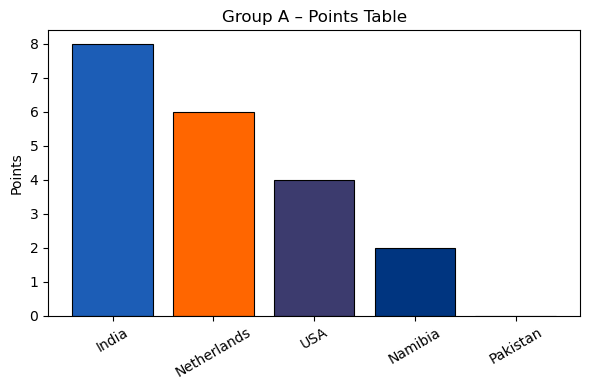

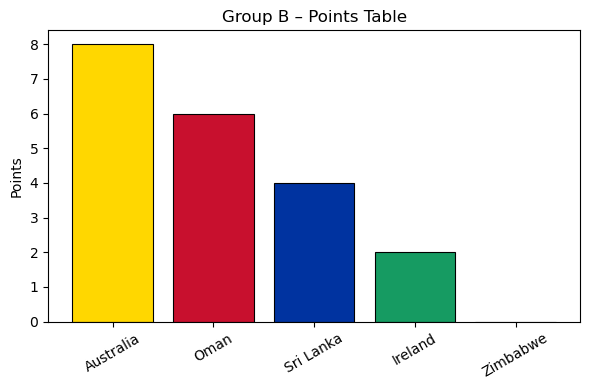

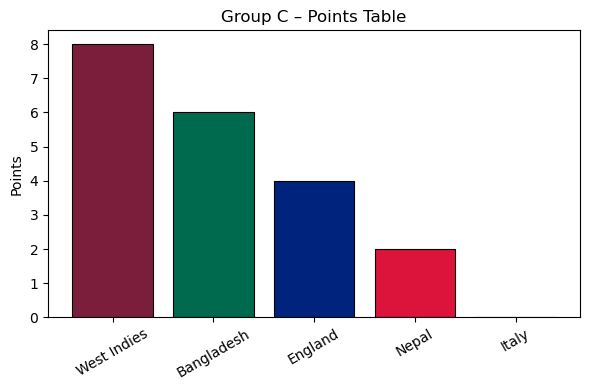

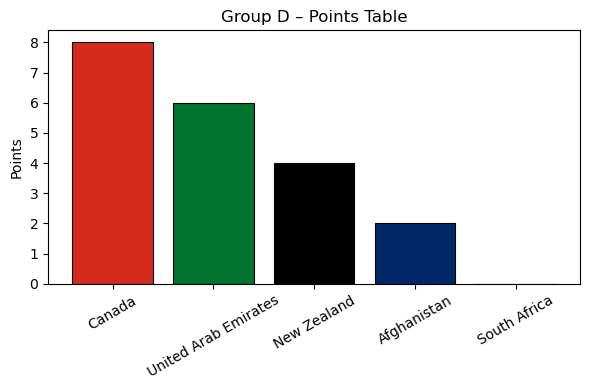

In [68]:
for grp, table in group_tables.items():
    colors = [team_colors.get(team, "#808080") for team in table["Team"]]

    plt.figure(figsize=(6, 4))
    plt.bar(
        table["Team"],
        table["Points"],
        color=colors,
        edgecolor="black",
        linewidth=0.8
    )
    plt.title(f"Group {grp} – Points Table")
    plt.ylabel("Points")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [46]:
def simulate_match_expected(team1, team2):
    X = build_match_features(team1, team2)
    p_team1 = model.predict_proba(X)[0, 1]

    return {
        "Match": f"{team1} vs {team2}",
        "Team1": team1,
        "Team2": team2,
        "Team1 Win %": round(p_team1 * 100, 2),
        "Team2 Win %": round((1 - p_team1) * 100, 2),
        "Predicted Winner": team1 if p_team1 >= 0.5 else team2
    }

In [47]:
group_rankings = {}

for grp, table in group_tables.items():
    group_rankings[grp] = table.loc[:1, "Team"].tolist()

A1, A2 = group_rankings["A"]
B1, B2 = group_rankings["B"]
C1, C2 = group_rankings["C"]
D1, D2 = group_rankings["D"]

super8_groups = {
    "G1": [A1, B2, C1, D2],
    "G2": [A2, B1, C2, D1]
}

In [59]:
team_colors = {
    "India": "#1C5DB6",            # Blue
    "Australia": "#FFD700",        # Gold
    "England": "#00247D",          # Navy
    "Pakistan": "#006600",         # Green
    "South Africa": "#007A4D",     # Green
    "New Zealand": "#000000",      # Black
    "West Indies": "#7B1E3C",      # Maroon
    "Sri Lanka": "#0033A0",        # Blue
    "Bangladesh": "#006A4E",       # Green
    "Afghanistan": "#002868",      # Blue
    "Netherlands": "#FF6600",      # Orange
    "Oman": "#C8102E",             # Red
    "Ireland": "#169B62",          # Green
    "Zimbabwe": "#FCD116",         # Yellow
    "Nepal": "#DC143C",            # Crimson
    "Namibia": "#003580",          # Blue
    "United Arab Emirates": "#00732F",
    "USA": "#3C3B6E",               # Navy
    "Canada": "#D52B1E",            # Red
    "Italy": "#009246",             # Green
}

### SUPER 8

In [48]:
from itertools import combinations

super8_points = {}
super8_matches_won = {}
super8_match_logs = []

for grp, teams in super8_groups.items():
    super8_points[grp] = {t: 0 for t in teams}
    super8_matches_won[grp] = {t: 0 for t in teams}

    for t1, t2 in combinations(teams, 2):
        res = simulate_match_expected(t1, t2)
        winner = res["Predicted Winner"]

        super8_points[grp][winner] += 2
        super8_matches_won[grp][winner] += 1

        super8_match_logs.append({
            "Super 8 Group": grp,
            **res
        })

In [49]:
super8_matches_df = pd.DataFrame(super8_match_logs)
super8_matches_df

,Super 8 Group,Match,Team1,Team2,Team1 Win %,Team2 Win %,Predicted Winner
0,G1,India vs Oman,India,Oman,68.42,31.58,India
1,G1,India vs West Indies,India,West Indies,74.45,25.55,India
2,G1,India vs United Arab Emirates,India,United Arab Emirates,84.64,15.36,India
3,G1,Oman vs West Indies,Oman,West Indies,57.96,42.04,Oman
4,G1,Oman vs United Arab Emirates,Oman,United Arab Emirates,72.28,27.72,Oman
5,G1,West Indies vs United Arab Emirates,West Indies,United Arab Emirates,65.98,34.02,West Indies
6,G2,Netherlands vs Australia,Netherlands,Australia,30.97,69.03,Australia
7,G2,Netherlands vs Bangladesh,Netherlands,Bangladesh,45.73,54.27,Bangladesh
8,G2,Netherlands vs Canada,Netherlands,Canada,48.63,51.37,Canada
9,G2,Australia vs Bangladesh,Australia,Bangladesh,65.82,34.18,Australia


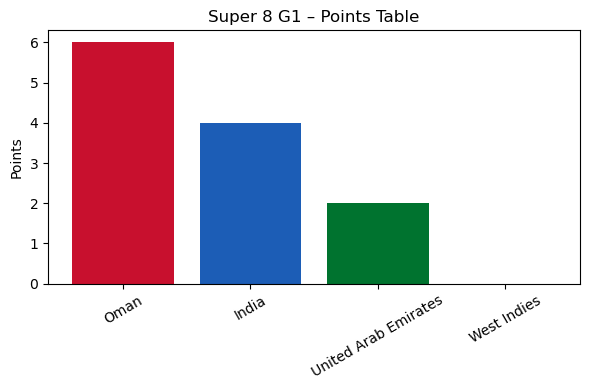

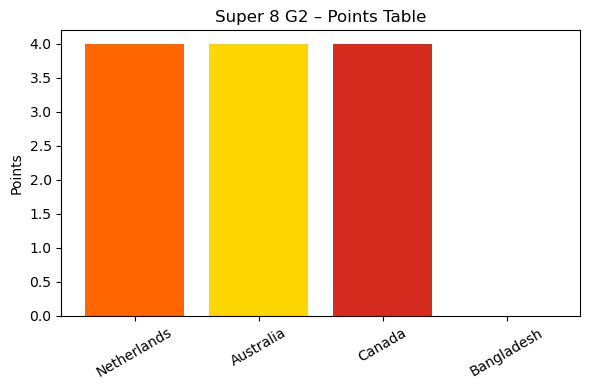

In [60]:
import matplotlib.pyplot as plt

for grp, table in super8_tables.items():
    colors = [team_colors.get(team, "#808080") for team in table["Team"]]

    plt.figure(figsize=(6, 4))
    plt.bar(table["Team"], table["Points"], color=colors)
    plt.title(f"Super 8 {grp} – Points Table")
    plt.ylabel("Points")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### Semi Finals

In [50]:
G1_winner, G1_runner = super8_tables["G1"].loc[0, "Team"], super8_tables["G1"].loc[1, "Team"]
G2_winner, G2_runner = super8_tables["G2"].loc[0, "Team"], super8_tables["G2"].loc[1, "Team"]

In [51]:
semi_fixtures = [
    (G1_winner, G2_runner),
    (G2_winner, G1_runner)
]

semi_finals_log = []

for t1, t2 in semi_fixtures:
    semi_finals_log.append(simulate_match_expected(t1, t2))

semi_finals_df = pd.DataFrame(semi_finals_log)
semi_finals_df

,Match,Team1,Team2,Team1 Win %,Team2 Win %,Predicted Winner
0,Oman vs Australia,Oman,Australia,48.86,51.14,Australia
1,Netherlands vs India,Netherlands,India,18.56,81.44,India


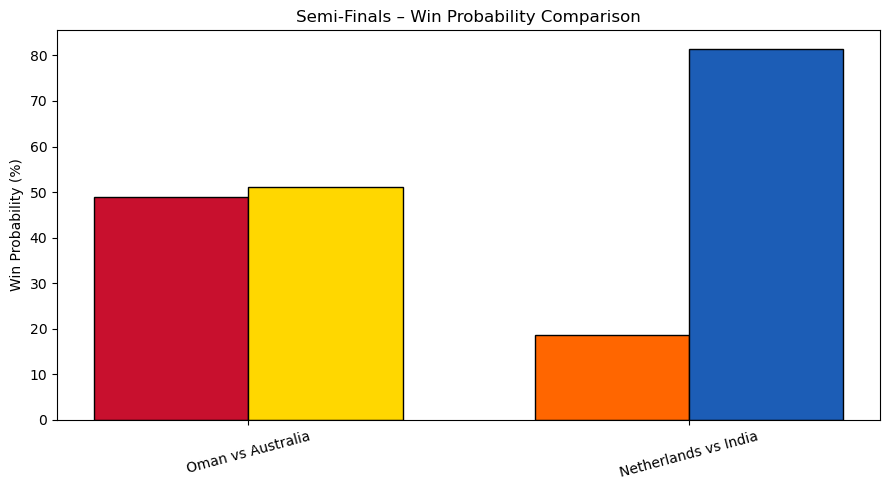

In [63]:
import numpy as np
import matplotlib.pyplot as plt

matches = semi_finals_df["Match"].tolist()
team1_probs = semi_finals_df["Team1 Win %"].tolist()
team2_probs = semi_finals_df["Team2 Win %"].tolist()

team1_names = semi_finals_df["Team1"].tolist()
team2_names = semi_finals_df["Team2"].tolist()

x = np.arange(len(matches))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, team1_probs, width, label="Team 1", color=colors1, edgecolor="black")
plt.bar(x + width/2, team2_probs, width, label="Team 2", color=colors2, edgecolor="black")

plt.xticks(x, matches, rotation=15)
plt.ylabel("Win Probability (%)")
plt.title("Semi-Finals – Win Probability Comparison")
plt.tight_layout()
plt.show()

### Finals

In [52]:
finalists = semi_finals_df["Predicted Winner"].tolist()

final_res = simulate_match_expected(finalists[0], finalists[1])

final_df = pd.DataFrame([{
    "Match": final_res["Match"],
    "Team1 Win %": final_res["Team1 Win %"],
    "Team2 Win %": final_res["Team2 Win %"],
    "Champion": final_res["Predicted Winner"]
}])

final_df

,Match,Team1 Win %,Team2 Win %,Champion
0,Australia vs India,34.24,65.76,India


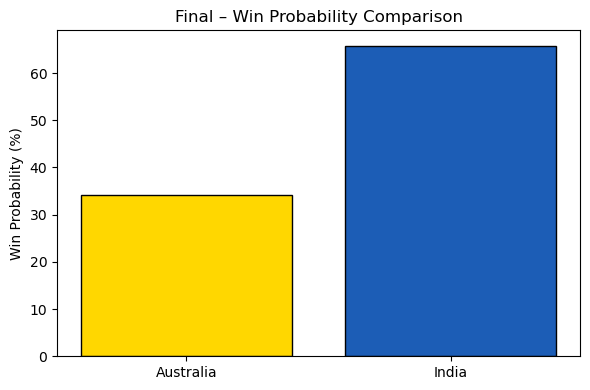

In [64]:
team1, team2 = final_df.loc[0, "Match"].split(" vs ")
team1_prob = final_df.loc[0, "Team1 Win %"]
team2_prob = final_df.loc[0, "Team2 Win %"]

plt.figure(figsize=(6, 4))
plt.bar(
    [team1, team2],
    [team1_prob, team2_prob],
    color=[team_colors.get(team1, "#808080"), team_colors.get(team2, "#808080")],
    edgecolor="black"
)
plt.ylabel("Win Probability (%)")
plt.title("Final – Win Probability Comparison")
plt.tight_layout()
plt.show()

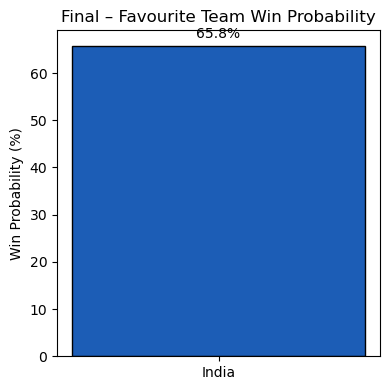

In [66]:
if team1_prob >= team2_prob:
    fav_team, fav_prob = team1, team1_prob
else:
    fav_team, fav_prob = team2, team2_prob

plt.figure(figsize=(4, 4))
plt.bar(
    [fav_team],
    [fav_prob],
    color=team_colors.get(fav_team, "#808080"),
    edgecolor="black"
)
plt.text(
    0, fav_prob + 1,
    f"{fav_prob:.1f}%",
    ha="center", va="bottom", fontsize=10
)

plt.ylabel("Win Probability (%)")
plt.title("Final – Favourite Team Win Probability")
plt.tight_layout()
plt.show()